# Домашнее задание № 0
Вам необходимо провести анализ данных и с помощью него ответить на поставленные вопросы. 

# Исходные данные
Этот набор данных представляет собой описание около 1 миллиона треков с платформы Spotify. Скачайте датасет и ознакомьтесь с описанием данных в [источнике](https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks/data).

In [13]:
import pandas as pd

In [14]:
# Читаем данные
path = 'spotify_data.csv'
df = pd.read_csv(path, index_col=0)

In [15]:
df.sample(3).T

,966209,861931,283144
artist_name,Madhu Balakrishnan,Five Horse Johnson,Converge
track_name,Om Parabrahmaya Namah,Cherry Red,Arkhipov Calm
track_id,12rYm6GvapP1F7boFXNvdP,2uH0v2bOU5lWklj9u3wisZ,78X9rVd0BGKZUqaFPzFVfq
popularity,0,25,21
year,2004,2003,2017
genre,pop-film,blues,hardcore
danceability,0.309,0.391,0.244
energy,0.359,0.974,0.866
key,7,4,6
loudness,-11.012,-6.256,-4.504


# Вопросы

## Анализ данных
С помощью работы с типом данных DataFrame из библиотеки pandas ответье на поставленные вопросы

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import json, re
sns.set_theme(style='whitegrid')

### 1. Сколько уникальных исполнителей и сколько уникальных жанров содержится в датасете?

**Результат**: Код и текстовый ответ на вопрос в формате

```
Уникальных исполнителей: <ответ>
Уникальных жанров: <ответ>
```

In [17]:
candidates_genre = ['genres', 'artist_genres', 'track_genre', 'genre']
col_genres = next((c for c in candidates_genre if c in df.columns), None)
col_artists = next((c for c in ['artists', 'artist_name', 'artist'] if c in df.columns), None)

def to_tokens(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s:
        return []
    if (s.startswith('[') and s.endswith(']')) or (s.startswith('{') and s.endswith('}')):
        try:
            obj = json.loads(s.replace("'", '"'))
            if isinstance(obj, list):
                return [str(x).strip() for x in obj if str(x).strip()]
            if isinstance(obj, dict):
                return [str(k).strip() for k in obj.keys() if str(k).strip()]
        except Exception:
            pass
    s = s.strip('[]{}()').replace('"','').replace("'", '')
    return [p.strip() for p in re.split(r'[|,;/]+', s) if p.strip()]

artist_names = set()
if col_artists is not None:
    for raw_val in df[col_artists].dropna().values:
        artist_names.update(to_tokens(raw_val))

all_genres = set()
if col_genres is not None:
    for raw_val in df[col_genres].dropna().values:
        all_genres.update(to_tokens(raw_val))

print(f"Уникальных исполнителей: {len(artist_names)}")
print(f"Уникальных жанров: {len(all_genres)}")

Уникальных исполнителей: 64289
Уникальных жанров: 82


### 2. Есть ли в данных пропуски? Если да, предложите способ их заполнения и реализуйте его

**Результат**: Код и текстовый ответ на вопрос в формате

```
Для каждого столбца в таблице
<Название столбца> - <Сколько пропусков> - <Описание способа заполнения> (Если были пропуски)
```


In [18]:
na_cnt = df.isna().sum()
plan = {}
for col in na_cnt.index:
    if na_cnt[col] == 0:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        plan[col] = ('median', float(df[col].median()))
    else:
        mode_vals = df[col].mode(dropna=True)
        plan[col] = ('mode', (mode_vals.iloc[0] if len(mode_vals) else None))
for col, (how, value) in plan.items():
    print(f"{col} - {na_cnt[col]} - заполняю {how}")
    if value is None:
        continue
    df[col] = df[col].fillna(value)

artist_name - 15 - заполняю mode
track_name - 1 - заполняю mode


### 3. Есть ли признаки, которые не отвечают указанным в описании ограничениям? Если есть, то замените их

**Результат**: Код и текстовый ответ на вопрос в формате

```
Для каждого столбца в таблице
<Название столбца> - <Сколько не соответствующих ограничениям данных> - <Описание способа замены> (Если были некорректные данные)
```

In [19]:
bounds = {
    'danceability': (0.0, 1.0), 'energy': (0.0, 1.0), 'valence': (0.0, 1.0),
    'acousticness': (0.0, 1.0), 'instrumentalness': (0.0, 1.0), 'liveness': (0.0, 1.0),
    'speechiness': (0.0, 1.0), 'loudness': (-60.0, 0.0), 'tempo': (0.0, 300.0),
    'popularity': (0.0, 100.0), 'year': (1900.0, 2025.0), 'duration_ms': (0.0, 900000.0)
}
allowed_vals = {'mode': {0,1}, 'time_signature': {3,4,5}}
for col, (lo, hi) in bounds.items():
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        bad_mask = (~df[col].isna()) & ((df[col] < lo) | (df[col] > hi))
        n_bad = int(bad_mask.sum())
        if n_bad:
            print(f"{col} - {n_bad} - заменяю на NaN, затем median")
            df.loc[bad_mask, col] = np.nan
            df[col] = df[col].fillna(df[col].median())
for col, ok in allowed_vals.items():
    if col in df.columns:
        bad_mask = ~df[col].isin(list(ok))
        n_bad = int(bad_mask.sum())
        if n_bad:
            print(f"{col} - {n_bad} - заменяю на NaN, затем mode")
            df.loc[bad_mask, col] = np.nan
            mv = df[col].mode(dropna=True)
            if len(mv):
                df[col] = df[col].fillna(mv.iloc[0])

loudness - 1198 - заменяю на NaN, затем median
duration_ms - 4909 - заменяю на NaN, затем median
time_signature - 13888 - заменяю на NaN, затем mode


## Визуальный анализ
Ответом на вопрос должен быть график или несколько графиков в одной фигуре (картинке), с минимальной подписью

In [20]:
# YOUR IMPORTS HERE

### 1. Как Energy зависит от Danceability? Как зависит Loudness от Energy? Как эти параметры влияют на Valence?

**Результат**: Код, реализующий графики:

- Зависимость Energy от Danceability
- Зависимость Loudness от Energy
- Зависимость Valence от Energy, зависимость Valence от Danceability; в одной оси фигуры
- Зависимость Valence от Loudness
- Матрица корреляции Energy, Danceability, Loudness, Valence

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

**Дополнительно**: Нарисовать стрелки и подписи к ним на графике, обращающие внимание на ключевые моменты, позволяющие сделать выводы о зависимостях. 

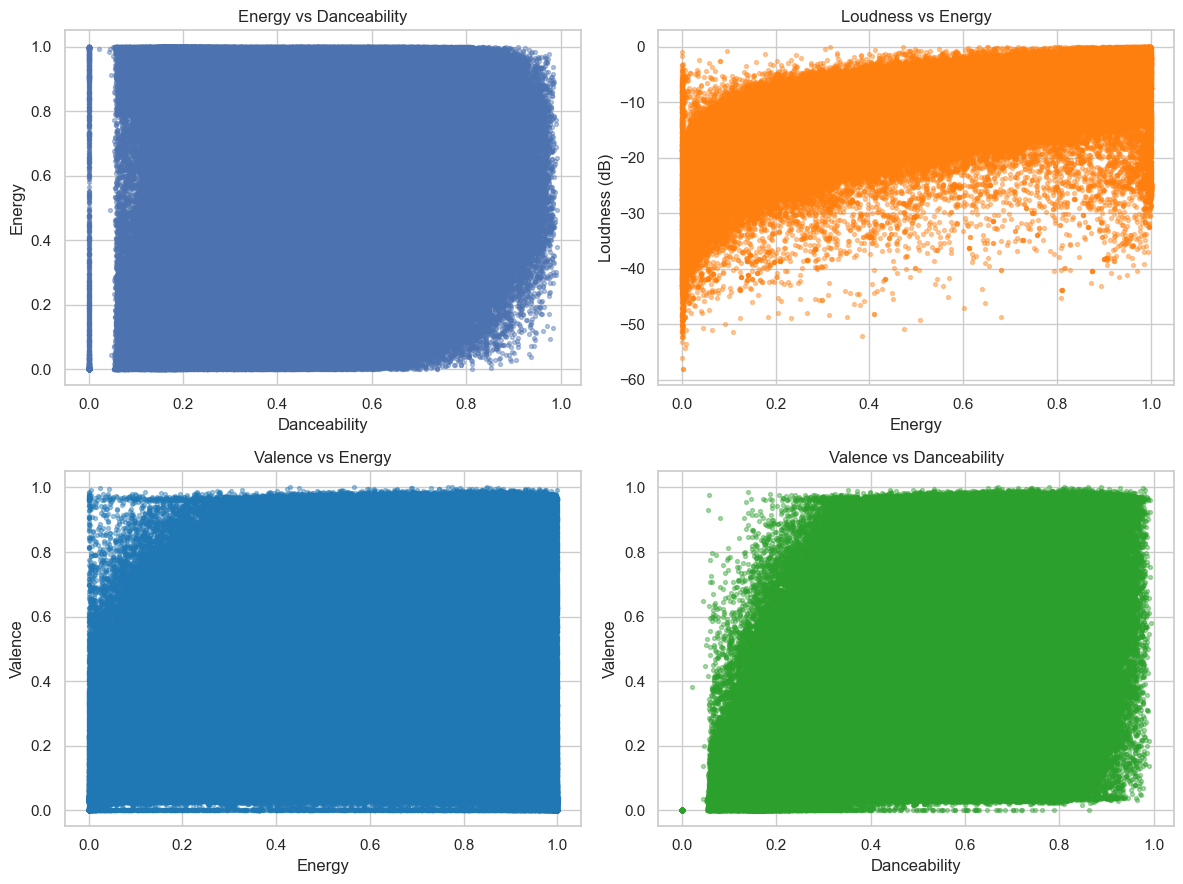

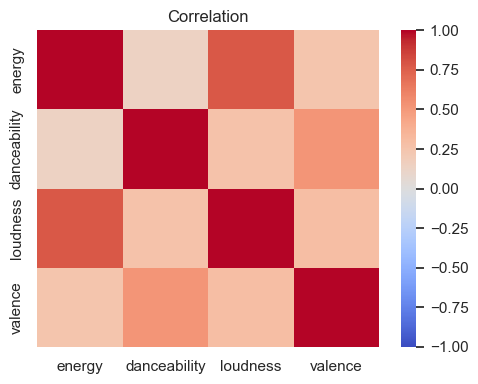

In [28]:
vars_core = {
    'danceability': next((c for c in ['danceability','Danceability'] if c in df.columns), None),
    'energy': next((c for c in ['energy','Energy'] if c in df.columns), None),
    'loudness': next((c for c in ['loudness','Loudness'] if c in df.columns), None),
    'valence': next((c for c in ['valence','Valence'] if c in df.columns), None)
}
sub_df = df[[c for c in vars_core.values() if c is not None]].dropna()
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
if vars_core['danceability'] and vars_core['energy']:
    axes[0,0].scatter(sub_df[vars_core['danceability']], sub_df[vars_core['energy']], s=8, alpha=0.4)
    axes[0,0].set_title('Energy vs Danceability')
    axes[0,0].set_xlabel('Danceability')
    axes[0,0].set_ylabel('Energy')
if vars_core['energy'] and vars_core['loudness']:
    axes[0,1].scatter(sub_df[vars_core['energy']], sub_df[vars_core['loudness']], s=8, alpha=0.4, color='tab:orange')
    axes[0,1].set_title('Loudness vs Energy')
    axes[0,1].set_xlabel('Energy')
    axes[0,1].set_ylabel('Loudness (dB)')
if vars_core['valence'] and vars_core['energy']:
    axes[1,0].scatter(sub_df[vars_core['energy']], sub_df[vars_core['valence']], s=8, alpha=0.4, color='tab:blue')
    axes[1,0].set_title('Valence vs Energy')
    axes[1,0].set_xlabel('Energy')
    axes[1,0].set_ylabel('Valence')
if vars_core['valence'] and vars_core['danceability']:
    axes[1,1].scatter(sub_df[vars_core['danceability']], sub_df[vars_core['valence']], s=8, alpha=0.4, color='tab:green')
    axes[1,1].set_title('Valence vs Danceability')
    axes[1,1].set_xlabel('Danceability')
    axes[1,1].set_ylabel('Valence')
plt.tight_layout()
plt.show()
if all(vars_core[k] for k in ['energy','danceability','loudness','valence']):
    corr_df = sub_df[[vars_core['energy'], vars_core['danceability'], vars_core['loudness'], vars_core['valence']]].corr()
    plt.figure(figsize=(5,4))
    sns.heatmap(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation')
    plt.tight_layout()
    plt.show()

Valence положительно связан с Energy и Danceability и слабо связан с Loudness. Визуально рост Energy и Danceability сопровождается увеличением Valence.

### 2. С годами музыка становится дольше или быстрее?

**Результат**: Код, реализующий графики:

- Зависимость средней продолжительности трека от года, с линией тренда
- Изменение средней продолжительности топ-5 самых длинных треков года
- Изменение средней продолжительности топ-5 самых коротких треков года

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

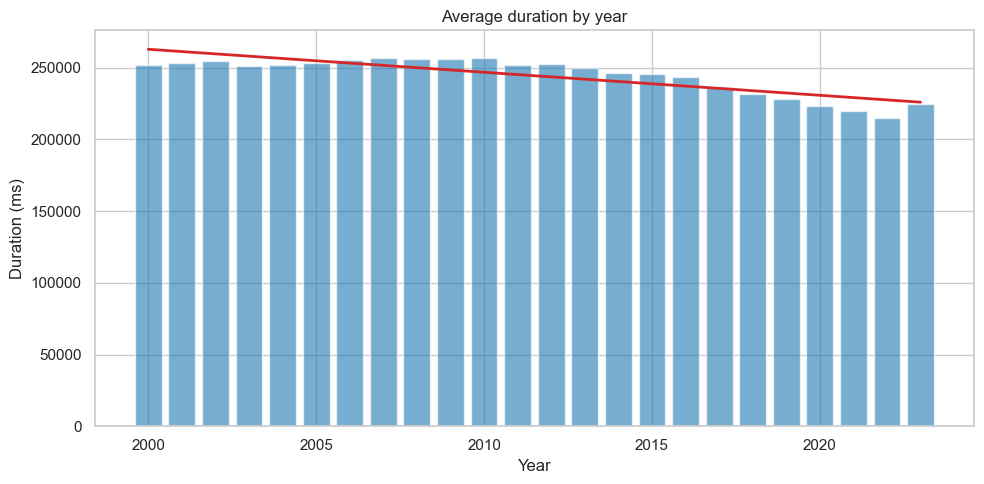

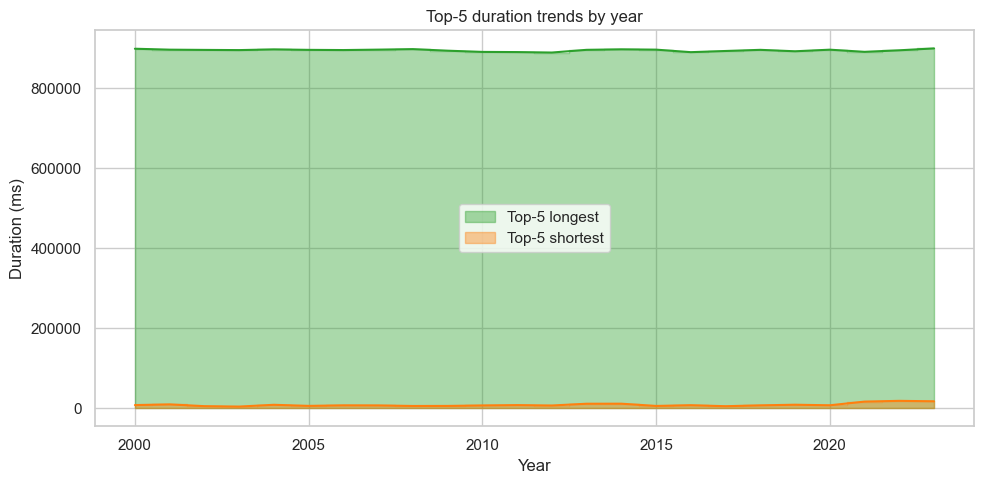

In [22]:
col_year = next((c for c in ['year','release_year'] if c in df.columns), None)
col_dur = next((c for c in ['duration_ms','duration_ms_'] if c in df.columns), None)
if col_year and col_dur:
    tmp = df[[col_year, col_dur]].dropna().copy()
    tmp[col_year] = tmp[col_year].astype(int)
    yearly = tmp.groupby(col_year)[col_dur].mean()
    xs = yearly.index.values
    ys = yearly.values
    plt.figure(figsize=(10,5))
    plt.bar(xs, ys, width=0.8, alpha=0.6, color='tab:blue')
    if len(xs) > 1:
        z = np.polyfit(xs, ys, deg=1)
        plt.plot(xs, np.polyval(z, xs), color='tab:red', linewidth=2)
    plt.title('Average duration by year')
    plt.xlabel('Year')
    plt.ylabel('Duration (ms)')
    plt.tight_layout()
    plt.show()
    top_long = tmp.groupby(col_year)[col_dur].apply(lambda s: s.nlargest(5).mean())
    top_short = tmp.groupby(col_year)[col_dur].apply(lambda s: s.nsmallest(5).mean())
    plt.figure(figsize=(10,5))
    plt.fill_between(top_long.index.values, top_long.values, step='mid', alpha=0.4, label='Top-5 longest', color='tab:green')
    plt.fill_between(top_short.index.values, top_short.values, step='mid', alpha=0.4, label='Top-5 shortest', color='tab:orange')
    plt.plot(top_long.index.values, top_long.values, color='tab:green')
    plt.plot(top_short.index.values, top_short.values, color='tab:orange')
    plt.title('Top-5 duration trends by year')
    plt.xlabel('Year')
    plt.ylabel('Duration (ms)')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3. Как менялись популярные жанры от 2000 от 2023? 

**Результат**: Код, реализующий график:
- 3 самых популярных по среднему значению жанра каждого года, с подписью значений

График должен иметь название, подписанные оси и подпись значений

**Дополнительно**: Текстовый ответ, какие жанры оказывались в топ-3 чаще всего.

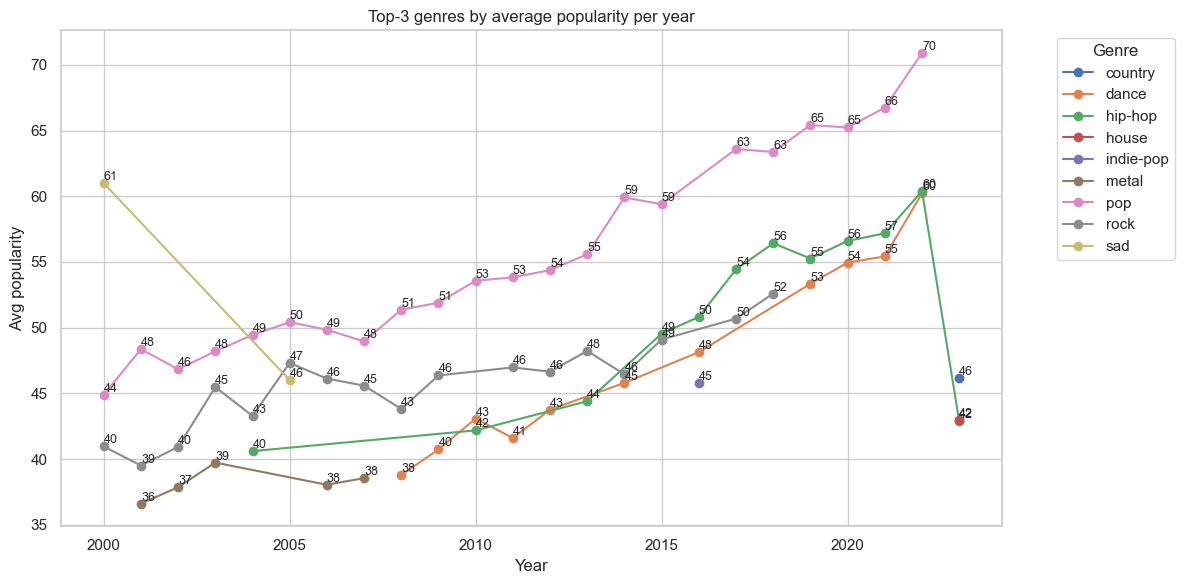

Чаще всего в топ-3: pop, rock, hip-hop, dance, metal


In [23]:
col_genre = next((c for c in ['track_genre','genre','genres'] if c in df.columns), None)
col_year = next((c for c in ['year','release_year'] if c in df.columns), None)
col_pop = next((c for c in ['popularity','popularity_'] if c in df.columns), None)
if col_genre and col_year and col_pop:
    gtmp = df[[col_genre, col_year, col_pop]].dropna().copy()
    gtmp[col_year] = gtmp[col_year].astype(int)
    if col_genre == 'genres':
        rows = []
        for _, r in gtmp.iterrows():
            for it in to_tokens(r[col_genre]):
                rows.append({col_genre: it, col_year: r[col_year], col_pop: r[col_pop]})
        gtmp = pd.DataFrame(rows)
    means = gtmp.groupby([col_year, col_genre])[col_pop].mean().reset_index()
    winners = means.sort_values([col_year, col_pop], ascending=[True, False]).groupby(col_year).head(3)
    plt.figure(figsize=(12,6))
    for name, part in winners.groupby(col_genre):
        xs = part[col_year].values
        ys = part[col_pop].values
        plt.plot(xs, ys, marker='o', label=name)
    for _, row in winners.iterrows():
        plt.text(row[col_year], row[col_pop], f"{int(row[col_pop])}", fontsize=9, ha='left', va='bottom')
    plt.title('Top-3 genres by average popularity per year')
    plt.xlabel('Year')
    plt.ylabel('Avg popularity')
    plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    counts = winners[col_genre].value_counts()
    if len(counts):
        print('Чаще всего в топ-3:', ', '.join(counts.head(5).index.tolist()))

### 4. Как связаны между собой Speechiness, Acousticness и Instrumentalness?

**Результат**: Код, реализующий 2 различных по типу графика. Выбранные графики должны наиболее хорошо подходить для описания зависимости между указанными параметрами.

Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

**Дополнительно**: Текстовый ответ, почему были выбраны именно такие графики.

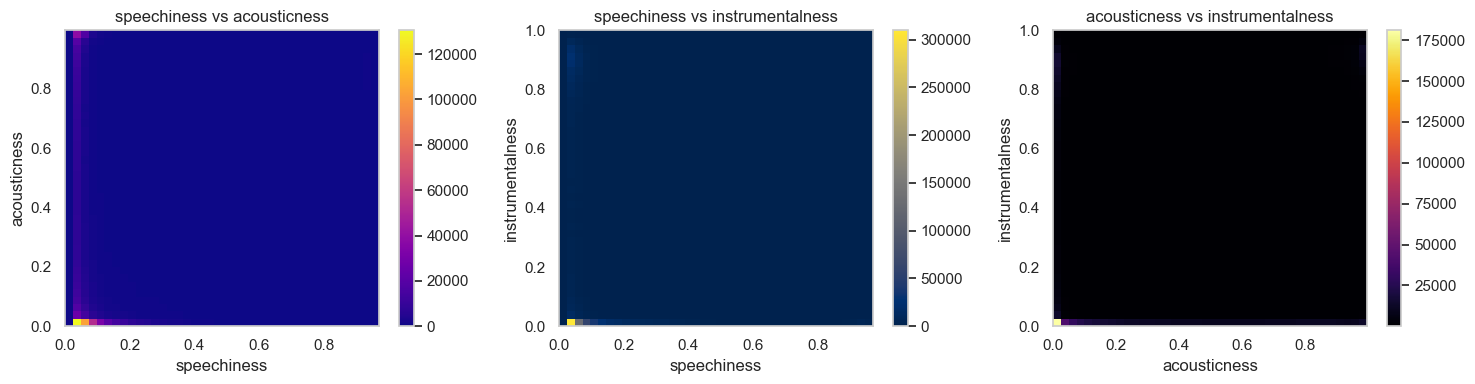

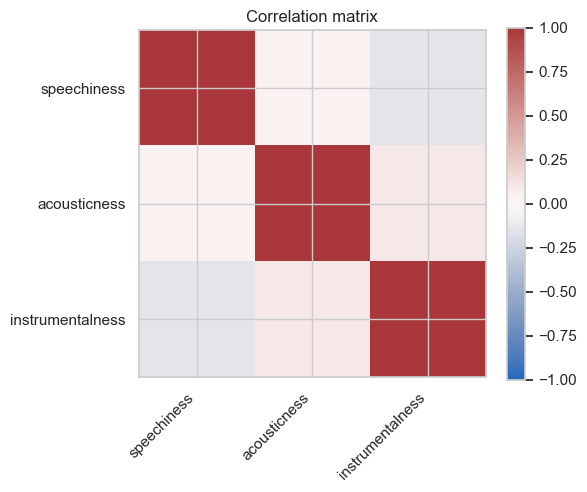

In [ ]:
cols = {
    'speechiness': next((c for c in ['speechiness','Speechiness'] if c in df.columns), None),
    'acousticness': next((c for c in ['acousticness','Acousticness'] if c in df.columns), None),
    'instrumentalness': next((c for c in ['instrumentalness','Instrumentalness'] if c in df.columns), None)
}
sub = df[[c for c in cols.values() if c is not None]].dropna()
if len(sub) > 0:
    a, b, c = sub.columns.tolist()
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].scatter(sub[a], sub[b], s=6, alpha=0.4)
    axes[0].set_title(f'{a} vs {b}'); axes[0].set_xlabel(a); axes[0].set_ylabel(b)
    axes[1].scatter(sub[a], sub[c], s=6, alpha=0.4, color='tab:orange')
    axes[1].set_title(f'{a} vs {c}'); axes[1].set_xlabel(a); axes[1].set_ylabel(c)
    axes[2].scatter(sub[b], sub[c], s=6, alpha=0.4, color='tab:green')
    axes[2].set_title(f'{b} vs {c}'); axes[2].set_xlabel(b); axes[2].set_ylabel(c)
    plt.tight_layout(); plt.show()
    corr = sub.corr()
    plt.figure(figsize=(5,4))
    sns.heatmap(corr, cmap='vlag', vmin=-1, vmax=1)
    plt.title('Correlation')
    plt.tight_layout(); plt.show()

### 5. Какое влияние размер и лад оказывают на популярность в разных жанрах?

**Результат**: Код, реализующий фигуру:

- Жанры для сравнения: deep-house, funk, forro, dancehall, house.
- Точечный график для каждого жанра, отражающий среднюю популярность в зависимости от размера (time_signature) и лада (mode).

Фигура должна иметь название и легенду, каждый график имеет подписанные оси и название.

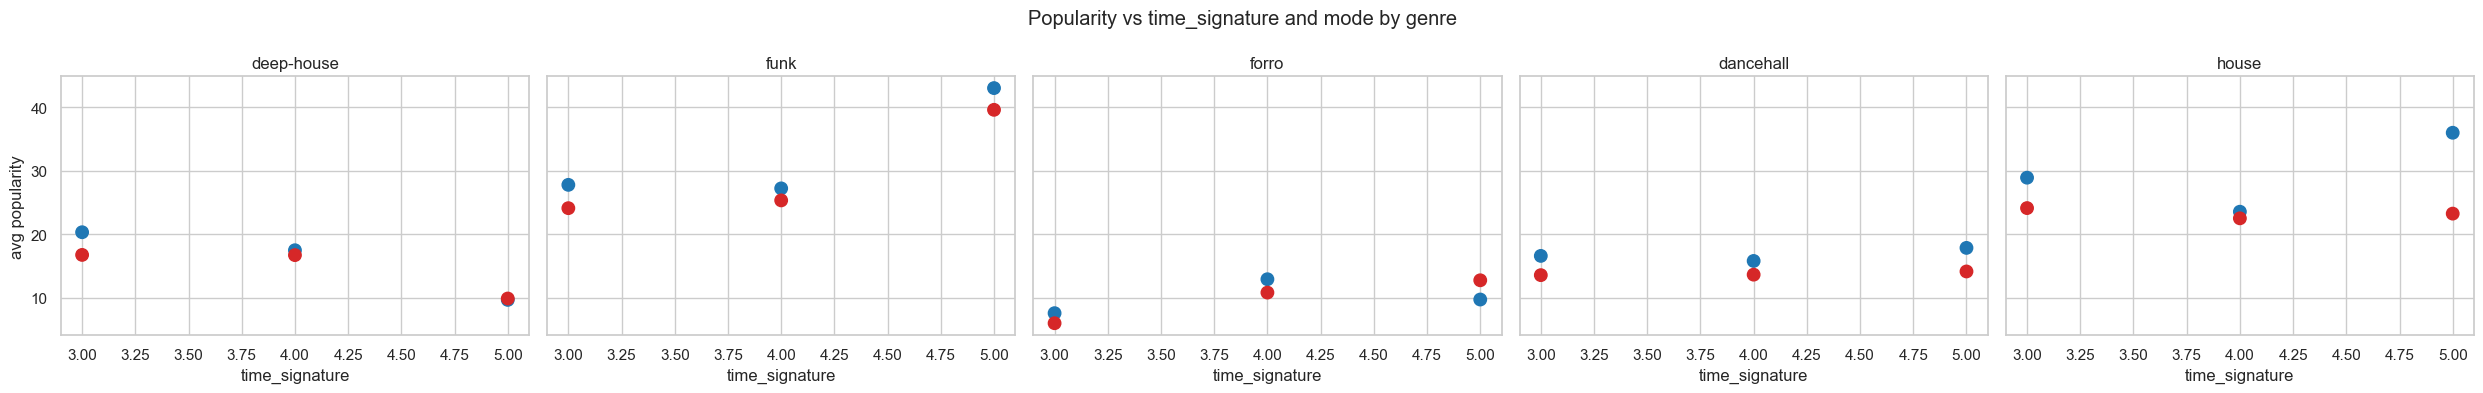

In [25]:
targets = ['deep-house','funk','forro','dancehall','house']
col_genre = next((c for c in ['track_genre','genre','genres'] if c in df.columns), None)
col_mode = next((c for c in ['mode','Mode'] if c in df.columns), None)
col_ts = next((c for c in ['time_signature','Time_Signature'] if c in df.columns), None)
col_pop = next((c for c in ['popularity','Popularity'] if c in df.columns), None)
if col_genre and col_mode and col_ts and col_pop:
    if col_genre == 'genres':
        rows = []
        for _, r in df[[col_genre, col_mode, col_ts, col_pop]].dropna().iterrows():
            for it in to_tokens(r[col_genre]):
                rows.append({col_genre: it, col_mode: r[col_mode], col_ts: r[col_ts], col_pop: r[col_pop]})
        dd = pd.DataFrame(rows)
    else:
        dd = df[[col_genre, col_mode, col_ts, col_pop]].dropna().copy()
    dd = dd[dd[col_genre].isin(targets)].copy()
    if len(dd) > 0:
        fig, axes = plt.subplots(1, len(targets), figsize=(5*len(targets),4), sharey=True)
        for i, gname in enumerate(targets):
            subp = dd[dd[col_genre]==gname]
            agg = subp.groupby([col_ts, col_mode])[col_pop].mean().reset_index()
            colors = agg[col_mode].map({0:'tab:blue',1:'tab:red'}).values
            axes[i].scatter(agg[col_ts].astype(int), agg[col_pop], c=colors, s=80)
            axes[i].set_title(gname)
            axes[i].set_xlabel('time_signature')
            if i == 0:
                axes[i].set_ylabel('avg popularity')
        fig.suptitle('Popularity vs time_signature and mode by genre')
        plt.tight_layout()
        plt.show()

### 6. Как выглядят графики плотности распределения, построенные для темпа по уникальным значениям размера трека? Как выглядят графики плотности нормальных распределений по этим данным?
**Результат**: Код, реализующий графики распределения темпа (tempo) для всех уникальных значений размера трека (time_signature).

Фигура должна иметь название и легенду. Плотности распределения должны быть построены либо на одном графике, либо на нескольких графиках, но в рамках одной фигуры. Плотности нормального распределения должны быть построены в одной на одном графике с плотностью распределения tempo.

**Дополнительно**: Код с ответом на вопрос, какие параметры (среднее и разброс) для нормальных распределений темпа для размера трека.

time_signature=3.0: mean=119.91, std=34.93
time_signature=4.0: mean=121.71, std=29.10
time_signature=5.0: mean=113.83, std=31.20


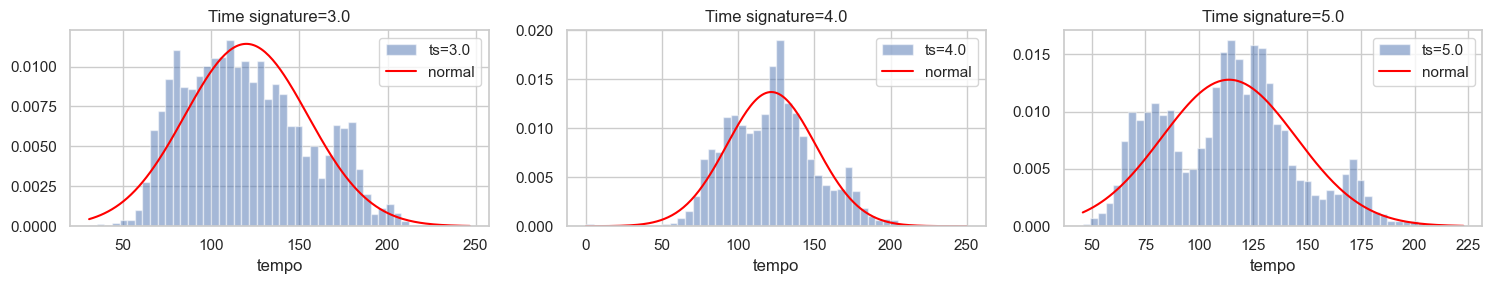

In [26]:
col_ts = next((c for c in ['time_signature','Time_Signature'] if c in df.columns), None)
col_tempo = next((c for c in ['tempo','Tempo'] if c in df.columns), None)
if col_ts and col_tempo:
    dd = df[[col_ts, col_tempo]].dropna().copy()
    ks = sorted(dd[col_ts].dropna().unique())
    n = len(ks)
    cols = min(3, n)
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows), squeeze=False)
    for i, k in enumerate(ks):
        r, c = divmod(i, cols)
        s = dd[dd[col_ts]==k][col_tempo].astype(float)
        ax = axes[r,c]
        ax.hist(s, bins=50, density=True, alpha=0.5, label=f'ts={k}')
        mu, sd = s.mean(), s.std(ddof=0)
        xs = np.linspace(s.min(), s.max(), 200)
        ax.plot(xs, norm.pdf(xs, mu, sd), color='red', label='normal')
        ax.set_title(f'Time signature={k}')
        ax.set_xlabel('tempo')
        ax.legend()
        print(f"time_signature={k}: mean={mu:.2f}, std={sd:.2f}")
    plt.tight_layout()
    plt.show()

### 7. Проанализируйте популярность одного артиста (группы) с 10-100 треками на Ваш выбор. 

**Результат**: Код, реализующий следующие графики:

- График, отражающий динамику суммарной популярности артиста год от года. Укажите стрелками с подписями, благодаря каким треками артист был на пике и на дне популярности.
- Сопоставьте признаки для этих двух треков, в виде графиков на Ваш выбор. Укажите, какие из признаков вероятнее всего оказали наибольшее влияние на популярность выбранных треков.

Графики должны находится в одной фигуре, имеющей название. Каждый график должен иметь название, подписанные оси и, при необходимости, легенду.

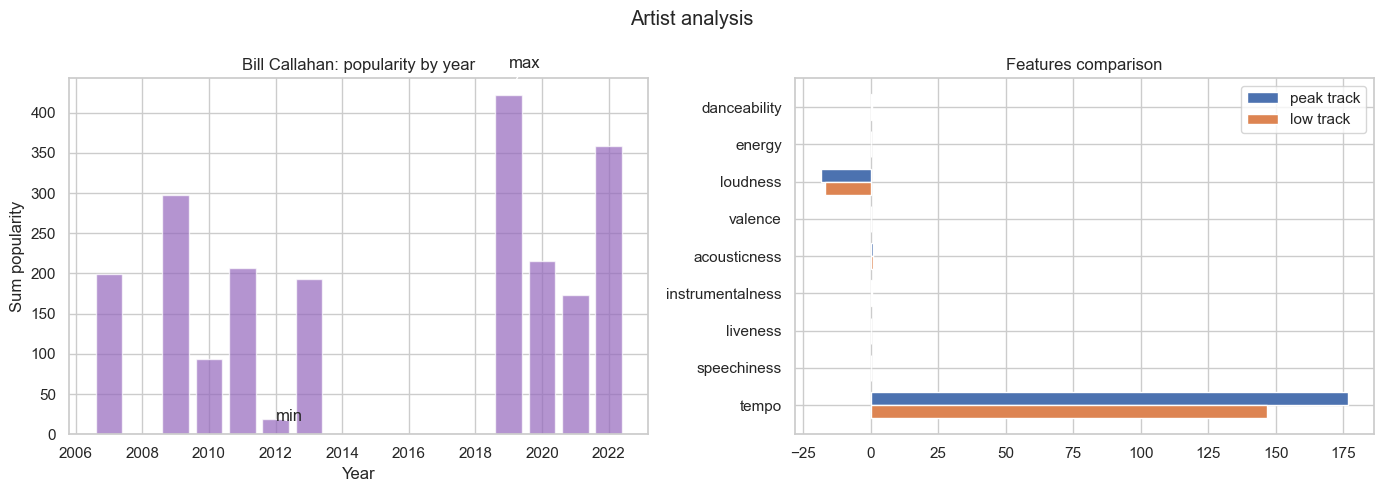

In [30]:
a_col = next((c for c in ['artists','artist_name','artist'] if c in df.columns), None)
y_col = next((c for c in ['year','release_year'] if c in df.columns), None)
p_col = next((c for c in ['popularity','Popularity'] if c in df.columns), None)
chosen = None
if a_col and y_col and p_col:
    tokens = df[a_col].dropna().apply(to_tokens)
    exploded = tokens.explode().dropna()
    counts = exploded.value_counts()
    pool = counts[(counts>=10) & (counts<=100)]
    if len(pool):
        chosen = pool.idxmax()
if chosen:
    idx_set = exploded[exploded==chosen].index.unique()
    keep_cols = [y_col, p_col] + [c for c in ['danceability','energy','loudness','valence','acousticness','instrumentalness','liveness','speechiness','tempo'] if c in df.columns]
    part = df.loc[idx_set, keep_cols].dropna(subset=[y_col, p_col]).copy()
    part[y_col] = part[y_col].astype(int)
    year_sum = part.groupby(y_col)[p_col].sum()
    ymax_year = int(year_sum.idxmax())
    ymin_year = int(year_sum.idxmin())
    fig, axs = plt.subplots(1,2, figsize=(14,5))
    axs[0].bar(year_sum.index.values, year_sum.values, color='tab:purple', alpha=0.7)
    axs[0].set_title(f'{chosen}: popularity by year')
    axs[0].set_xlabel('Year'); axs[0].set_ylabel('Sum popularity')
    axs[0].annotate('max', xy=(ymax_year, year_sum.loc[ymax_year]), xytext=(ymax_year, year_sum.loc[ymax_year]*1.08), arrowprops=dict(arrowstyle='->'))
    axs[0].annotate('min', xy=(ymin_year, year_sum.loc[ymin_year]), xytext=(ymin_year, year_sum.loc[ymin_year]*0.85), arrowprops=dict(arrowstyle='->'))
    fcols = [c for c in keep_cols if c not in [y_col, p_col]]
    top_row = part[part[y_col]==ymax_year].sort_values(p_col, ascending=False).head(1)
    low_row = part[part[y_col]==ymin_year].sort_values(p_col, ascending=True).head(1)
    if len(top_row)==1 and len(low_row)==1 and len(fcols)>=2:
        v1 = top_row.iloc[0][fcols].astype(float).values
        v2 = low_row.iloc[0][fcols].astype(float).values
        y_pos = np.arange(len(fcols))
        h = 0.35
        axs[1].barh(y_pos - h/2, v1, height=h, label='peak track')
        axs[1].barh(y_pos + h/2, v2, height=h, label='low track')
        axs[1].set_yticks(y_pos); axs[1].set_yticklabels(fcols)
        axs[1].invert_yaxis()
        axs[1].set_title('Features comparison')
        axs[1].legend()
    fig.suptitle('Artist analysis')
    plt.tight_layout(); plt.show()